# 06 — Returns & Performance

This notebook turns the **portfolio-vol-targeted weights** from Notebook 05 into a **strategy return series**, then evaluates performance (equity curve, drawdowns, rolling risk, rolling Sharpe) versus a simple benchmark (SPX).

Key timing note:

- In this project, **signals are lagged for trading** in Notebook 03.
- Asset vol estimates are also shifted to be **known at _t-1_** in Notebook 04.
- Portfolio scaling uses **portfolio vol _t-1_** in Notebook 05.

So the weights you load here are already intended to be **tradable on day _t_**, meaning you should usually compute portfolio returns as:

\[
r^{port}_t = \sum_i w_{i,t} \; r_{i,t}
\]

(i.e., **no additional `.shift(1)` on weights** unless you explicitly changed the timing assumptions.)


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from quant.config.strategy import TRADING_DAYS, TARGET_VOL_ANN
from quant.utils.alignment import align_on_index_and_columns
from quant.evaluation.performance import (
    equity_curve,
    performance_summary,
    rolling_vol,
    rolling_sharpe,
    drawdown_series,
)

WindowsPath('c:/Users/johng/code/quant-projects/quant-projects')

In [18]:
# --- Load inputs produced by earlier notebooks ---

w_port = pd.read_parquet("data/derived/weights_portfolio_vol_target.parquet")
rets = pd.read_parquet("data/processed/prices_simple_returns.parquet")

print("w_port:", w_port.shape)
print("rets:", rets.shape)

w_port: (5022, 15)
rets: (5022, 15)


In [19]:
# Align returns & weights (index + columns)
rets, w_port, audit = align_on_index_and_columns(
    rets, w_port, name_a="rets", name_b="w_port", audit=True
)
audit

=== Alignment audit ===
rets dates: 5,022 | w_port dates: 5,022 | Common: 5,022
rets cols : 15 | w_port cols : 15 | Common: 15

Dates only in rets: 0
Dates only in w_port: 0

Tickers only in rets: 0
Tickers only in w_port: 0


AlignmentAudit(n_rows_a=5022, n_rows_b=5022, n_rows_common=5022, n_cols_a=15, n_cols_b=15, n_cols_common=15, dates_only_in_a=DatetimeIndex([], dtype='datetime64[ms]', freq=None), dates_only_in_b=DatetimeIndex([], dtype='datetime64[ms]', freq=None), cols_only_in_a=Index([], dtype='str', name='ticker'), cols_only_in_b=Index([], dtype='str', name='ticker'))

In [ ]:
# --- Compute strategy returns ---
# IMPORTANT: weights are already tradable for day t in this project (signal + vol were lagged upstream),
# so we do NOT shift weights here.

port_ret = (w_port * rets).sum(axis=1)
port_ret.name = "portfolio_return"

# Basic sanity checks
print("Return NaN rate:", float(port_ret.isna().mean()))
print("Avg daily return:", float(port_ret.mean()))
print("Daily vol:", float(port_ret.std(ddof=1)))

# Initial returns should be zero as our weights are zero at the start (weights based on rolling vol)
port_ret.to_frame().head()

Return NaN rate: 0.0
Avg daily return: 0.00022414187241902824
Daily vol: 0.006722803860037722


,portfolio_return
2007-01-02,0.0
2007-01-03,0.0
2007-01-04,0.0
2007-01-05,0.0
2007-01-08,0.0


In [11]:
# Benchmark: SPX (if present in your universe)
bench = None
if "spx" in rets.columns:
    bench = rets["spx"].rename("spx")
else:
    print("No 'spx' column found in returns — benchmark plots will be skipped.")

bench.head() if bench is not None else None

2007-01-02         NaN
2007-01-03         NaN
2007-01-04    0.001228
2007-01-05   -0.006085
2007-01-08    0.002220
Name: spx, dtype: float64

In [12]:
# --- Headline performance summary ---
stats = pd.DataFrame(
    {
        "Strategy": performance_summary(port_ret, periods_per_year=TRADING_DAYS),
    }
)

if bench is not None:
    stats["SPX"] = performance_summary(bench, periods_per_year=TRADING_DAYS)

stats

,Strategy,SPX
CAGR,0.052092,0.082291
Vol,0.106721,0.193802
Sharpe,0.529265,0.505231
Sortino,0.849831,0.776669
MaxDD,-0.220633,-0.567754
Calmar,0.236103,0.144942


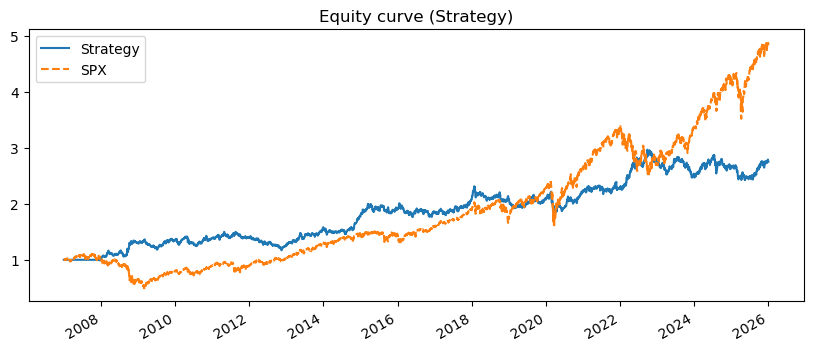

In [13]:
# --- Equity curve: Strategy vs Benchmark ---
ec = equity_curve(port_ret)

fig, ax = plt.subplots(figsize=(10, 4))
ec.plot(ax=ax, label="Strategy")
ax.set_title("Equity curve (Strategy)")

if bench is not None:
    equity_curve(bench).plot(ax=ax, label="SPX", linestyle="--")

ax.legend()
plt.show()

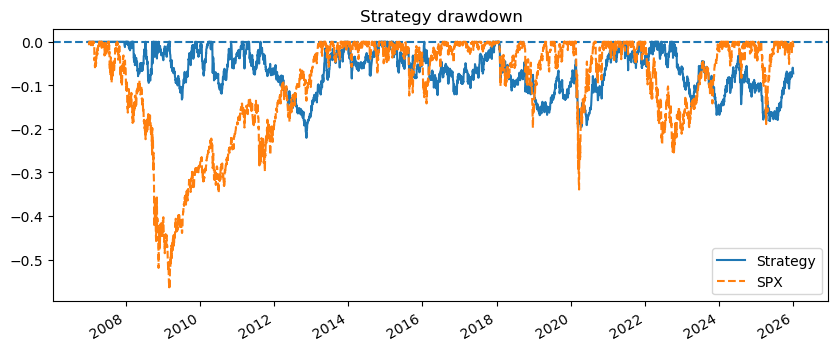

Max drawdown: -0.22063255104682167


In [23]:
# --- Drawdowns ---
dd = drawdown_series(port_ret)

fig, ax = plt.subplots(figsize=(10, 4))
dd.plot(ax=ax, label="Strategy")
ax.set_title("Strategy drawdown")
ax.axhline(0, linestyle="--")

if bench is not None:
    drawdown_series(bench).plot(ax=ax, label="SPX", linestyle="--")

ax.legend()
plt.show()

print("Max drawdown:", float(dd.min()))

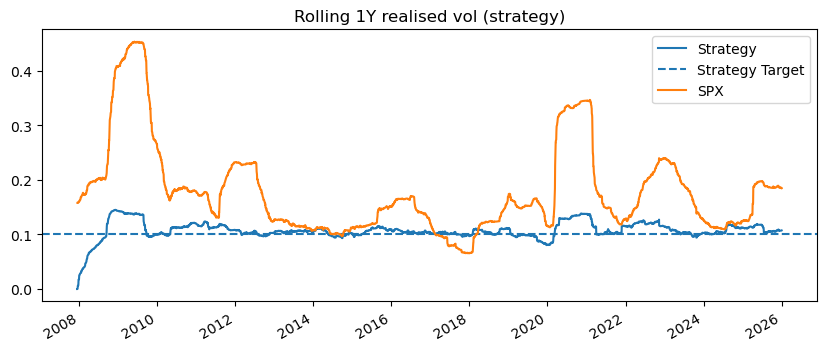

In [27]:
# --- Rolling realised vol: did targeting work? ---
rv = rolling_vol(port_ret, window=252, periods_per_year=TRADING_DAYS)

fig, ax = plt.subplots(figsize=(10, 4))
rv.plot(ax=ax, label="Strategy")
ax.axhline(TARGET_VOL_ANN, linestyle="--", label="Strategy Target")
ax.set_title("Rolling 1Y realised vol (strategy)")


if bench is not None:
    rolling_vol(bench, window=252, periods_per_year=TRADING_DAYS).plot(
        ax=ax, label="SPX"
    )

ax.legend()
plt.show()

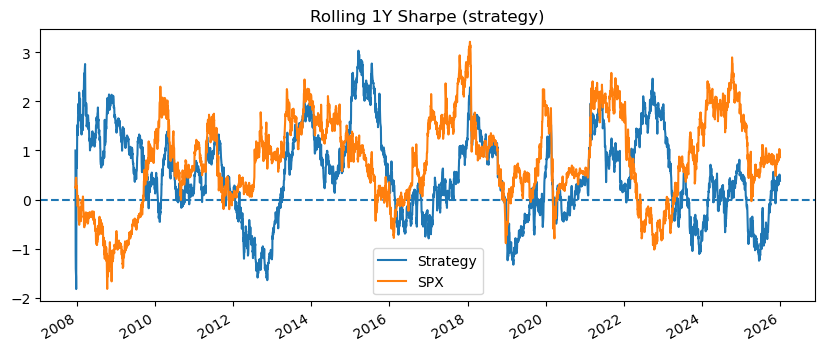

In [28]:
# --- Rolling Sharpe: stability of performance ---
rs = rolling_sharpe(port_ret, window=252, periods_per_year=TRADING_DAYS)

fig, ax = plt.subplots(figsize=(10, 4))
rs.plot(ax=ax, label="Strategy")
ax.axhline(0, linestyle="--")

if bench is not None:
    rolling_sharpe(bench, window=252, periods_per_year=TRADING_DAYS).plot(
        ax=ax, label="SPX"
    )

ax.set_title("Rolling 1Y Sharpe (strategy)")
ax.legend()
plt.show()

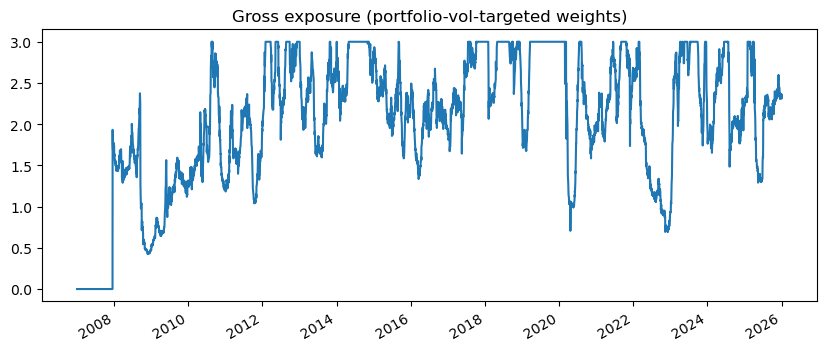

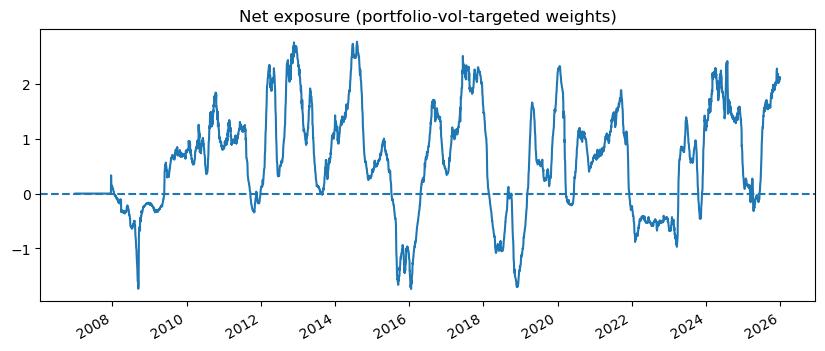

Avg gross: 2.07158998772317
Max gross: 3.0000000000000018


In [17]:
# --- Exposure diagnostics (gross / net) ---
gross = w_port.abs().sum(axis=1)
net = w_port.sum(axis=1)

fig, ax = plt.subplots(figsize=(10, 4))
gross.plot(ax=ax)
ax.set_title("Gross exposure (portfolio-vol-targeted weights)")
plt.show()

fig, ax = plt.subplots(figsize=(10, 4))
net.plot(ax=ax)
ax.axhline(0, linestyle="--")
ax.set_title("Net exposure (portfolio-vol-targeted weights)")
plt.show()

print("Avg gross:", float(gross.mean()))
print("Max gross:", float(gross.max()))